# Preprocess Annotated Annotated Data
Translate Label Studio JSON files to a format for ML & split into an 80/20 train/test split.

In [29]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

In [ ]:
ANNOTATED_DATA_JSON_PATH = "../data/input/annotations/annotated-1500-at-13-06-26.json"
TAXONOMY_PATH = "../data/output/taxonomy_autogen.csv"
FULL_DATA_OUTPUT_PATH = "../data/output/full_dataset.json"
TRAIN_OUTPUT_PATH = "../data/output/train_data_{0}.json"
TEST_OUTPUT_PATH = "../data/output/test_data_{0}.json"
STRIPPED_DATA_OUTPUT_PATH = "../data/output/stripped_annotated_data.csv"

RANDOM_STATE = 42

## Import from JSON file

In [31]:
with open(ANNOTATED_DATA_JSON_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

len(data)

1500

In [32]:
taxonomy = pd.read_csv(TAXONOMY_PATH)
taxonomy.head(5)

,high_level_category,category_description,values_hint,cat_label,regex
0,Care,Care experienced,"['Care leaver', 'Care experienced (under 25)']",care_care_experienced,\bcare experienced\b|\bcare leaver\b|\baged ou...
1,Care,Care setting,"['Fostered', 'Social care']",care_care_setting,\bfostered\b|\bfoster care\b|\bfoster placemen...
2,Care,Has caring responsibility,"['Formal', 'Informal']",care_has_caring_responsibility,\bformal carer\b|\bregistered carer\b|\bcarer....
3,Care,Social care involvement,"['Adult Social Care', ""Children's Social Care""]",care_social_care_involvement,\bsocial care\b|\bcare package\b|\bcare plan\b...
4,Cautions,ASBO or injunction obtained,"['ASBO', 'Injunction']",cautions_asbo_or_injunction_obtained,\bASBO\b|\binjunction\b|\bcivil injunction\b|\...


In [33]:
ENTITY_LABELS = {'Person_Name', 'Person_Role', 'Person_Pronoun'}
CAT_LABELS = set(taxonomy.cat_label.values.tolist())

records = []

for task in data:
    id = task['data']['id']
    text = task['data']['note_content']
    
    task_annotations = task['annotations']
    if len(task_annotations) == 0:
        continue
    elif len(task_annotations) > 1:
        annotation = min(task_annotations, key=lambda x: datetime.strptime(x['created_at'], "%Y-%m-%dT%H:%M:%S.%fZ"))
    else:
        annotation = task_annotations[0]
    
    needs = []
    entities = []
    relations = []
    seen_entities = set()

    for ann in annotation['result']:
        if ann['type'] == 'relation':
            relations.append({"from": ann['from_id'], "to": ann['to_id']})

        elif ann['type'] == 'labels':
            label = ann['value']['labels'][0]
            item = {
                "id": ann['id'],
                "start": ann['value']['start'],
                "end": ann['value']['end'],
                "label": label
            }

            if ann['from_name'] == 'need_labels' and label in CAT_LABELS:
                needs.append(item)
            elif ann['from_name'] == 'entity_labels' and label in ENTITY_LABELS:
                key = (ann['id'], label)
                if key not in seen_entities:
                    seen_entities.add(key)
                    entities.append(item)
            else:
                print(f"Skipping: {ann['from_name']}, {label} in {id}")

    records.append({"id": id, "text": text, "needs": needs, "entities": entities, "relations": relations})

In [34]:
records[5]

{'id': 'e2401f2c-fa87-6abd-0ce2-6053c459ead3',
 'text': "[Category: Tenancy Management] Re: Ryan Munoz DIR0146633\n\nEmilia-Alesia Marino <<EMAIL_ADDRESS>>\n<DATE_TIME>)\nto Yemi, Frances, Abigail Shaffer\n\nHi Gina Moore, \n\nAs discussed client is downstairs in Hackney Service Centre and Customer Services will be scanning Ms Lewis's Hospital Discharge papers.  Ms Lewis's Social Worker - Monique Tulloch will also be emailing you. \n\nThank you\n\n\nConnie Lawrence\nHostel Manager\nTemporary Accommodation\nBenefits and Housing Needs\nCustomer Services \n1 Hillman Street\n<LOCATION>\n<UK_POSTCODE>\n\ntelephone: <DATE_TIME>; <EMAIL_ADDRESS> \n\n\nOn Tue, <DATE_TIME> at 14:59, Gabrielle Davis <<EMAIL_ADDRESS>> wrote:\nHello Emilia, \n\nI can cancel the dod if client provide letter from hospital confirming that she was admitted at the hospital.\n\n\nRegards, \n\n\nOn Tue, <DATE_TIME> at 13:03, <LOCATION> <<EMAIL_ADDRESS>> wrote:\nHi Gina Moore, \n\nI've just received a call from the above 

## Count Duplicates (on note text)

In [35]:
# df = pd.DataFrame(records)
# df.duplicated(subset=['text']).value_counts()

In [36]:
# # Count lead time
# lead_times = [x['annotations'][0]['lead_time'] for x in data if len(x["annotations"]) > 0]
# sum(lead_times)/(60*60)

## Create Binary Label Matrix

In [37]:
def make_binary_label_matrix(raw_data, taxonomy_df):
    cat_labels = taxonomy_df['cat_label'].tolist()
    matrix_rows = []
    
    for record in raw_data:
        unique_labels = set(need['label'] for need in record.get('needs', [])) 
        
        row = {cat: (1 if cat in unique_labels else 0) for cat in cat_labels}
        matrix_rows.append(row)
        
    return pd.DataFrame(matrix_rows)

df_labels = make_binary_label_matrix(records, taxonomy)
df_labels.head()

,care_care_experienced,care_care_setting,care_has_caring_responsibility,care_social_care_involvement,cautions_asbo_or_injunction_obtained,cautions_dangerous_animals,cautions_physical_abuse_or_threat_of,cautions_unclean_unsafe_living_environment,cautions_verbal_abuse_or_threat_of,reasonable_adjustments_communication_needs,...,mobility_mobility_physical,mobility_service_need,property_level_property_adapted,property_level_disrepair_damp_mould,property_level_infestation,safety_risk_antisocial_behaviour,safety_risk_domestic_abuse,safety_risk_firerelated_risks,safety_risk_gas_capped,safety_risk_risk_of_exploitation
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


## Analyse distribution

,label,IRLbl
0,health_medical_condition,1.000000
1,property_level_disrepair_damp_mould,1.038095
2,safety_risk_antisocial_behaviour,1.090000
3,care_social_care_involvement,1.591241
4,health_care_setting,1.816667
5,health_mental_health,1.963964
6,mobility_mobility_physical,2.116505
7,life_events_temporary,2.158416
8,disability_requires_adapted_property,2.534884
9,life_events_life_events,2.691358


,Metric,Value
0,MeanIR,5.56
1,MaxIR,36.33
2,CVIR,1.03


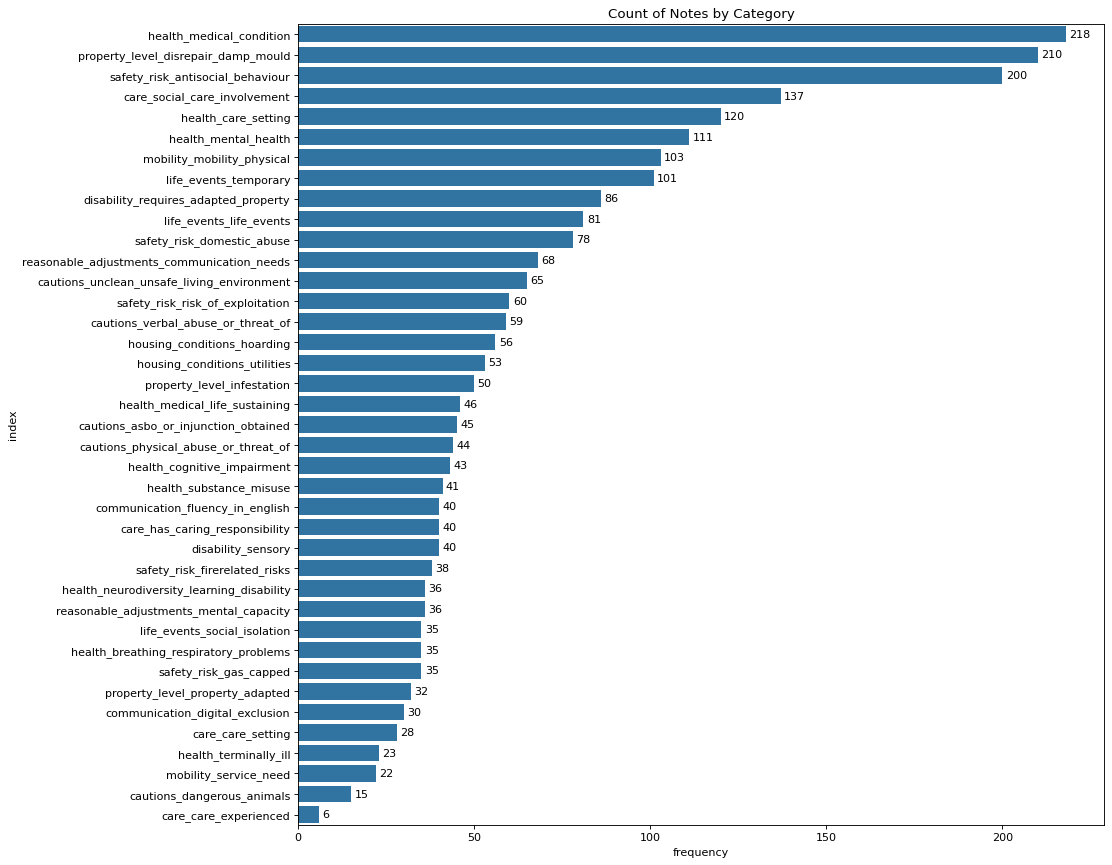

In [38]:
def analyze_category_distribution(df_labels):
    cat_value_counts = df_labels.sum(axis=0).reset_index(name="frequency").sort_values(by='frequency', ascending=False)

    # Calculate IRLbl per label (same as prep-gold-standard.ipynb)
    max_freq = cat_value_counts['frequency'].max()
    irlbl = max_freq / cat_value_counts['frequency']
    irlbl_df = pd.DataFrame({'label': cat_value_counts['index'].values, 'IRLbl': irlbl.values})
    display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))

    # Summary stats
    summary = pd.DataFrame({
        'Metric': ['MeanIR', 'MaxIR', 'CVIR'],
        'Value': [irlbl.mean(), irlbl.max(), irlbl.std() / irlbl.mean()]
    }).style.format({'Value': '{:.2f}'})
    display(summary)

    # Bar chart
    plt.figure(figsize=(13, 13), dpi=80)
    ax = sns.barplot(data=cat_value_counts, y='index', x='frequency', dodge=False)
    ax.bar_label(ax.containers[0], fmt='%.0f', padding=3) # type: ignore
    plt.title(f"Count of Notes by Category")
    plt.show()

analyze_category_distribution(df_labels)

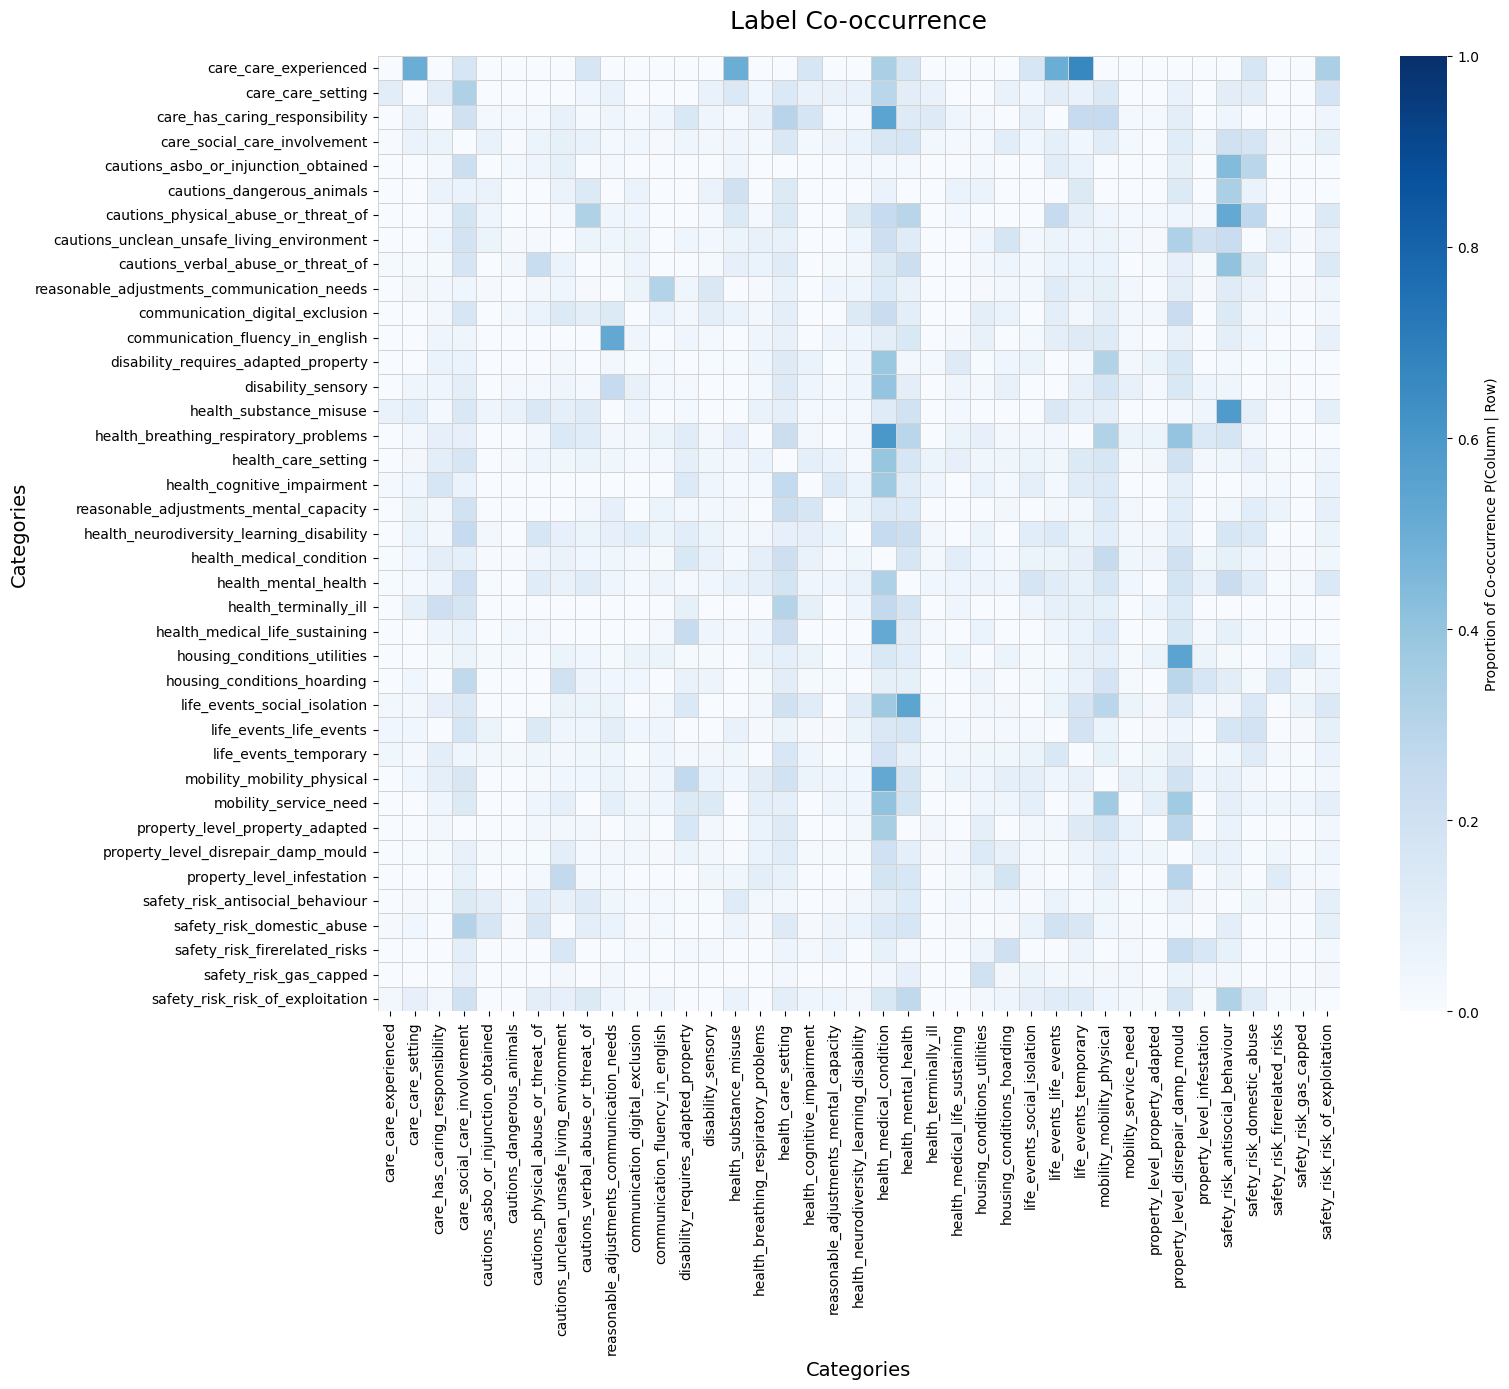

In [39]:
def show_co_occurence_heatmap(df_labels):
    # Calculate co-occurrence matrix by multiplying by transpose
    co_matrix = df_labels.T.dot(df_labels) 

    # Divide by class frequencies to yield conditional probability
    class_frequencies = np.diag(co_matrix) 
    normalized_matrix = co_matrix.div(class_frequencies, axis=0) 

    # Force diagonals to be 0s so they don't blow out the heatmap color scale
    normalized_matrix_arr = normalized_matrix.to_numpy(copy=True)
    np.fill_diagonal(normalized_matrix_arr, 0) 
    normalized_matrix = pd.DataFrame(normalized_matrix_arr, index=co_matrix.index, columns=co_matrix.columns)

    # Plot Heatmap
    plt.figure(figsize=(16, 14))
    sns.heatmap(
        normalized_matrix, 
        cmap="Blues", 
        annot=False, 
        linewidths=0.5, 
        linecolor='lightgrey',
        vmin=0, vmax=1, 
        cbar_kws={'label': 'Proportion of Co-occurrence P(Column | Row)'}
    )

    plt.title("Label Co-occurrence", fontsize=18, pad=20)
    plt.xlabel("Categories", fontsize=14)
    plt.ylabel("Categories", fontsize=14)

    plt.tight_layout()
    plt.show()

show_co_occurence_heatmap(df_labels)

In [40]:
# Dump all
with open(FULL_DATA_OUTPUT_PATH, "w") as f:
    json.dump(records, f, indent=2)


## Train/Test Split (80/20)

In [41]:
# Convert records into NumPy arrays for splitting
texts = np.array([r["text"] for r in records])

# Create labels
labels = df_labels.to_numpy()

# Train/Test split with Multi-Label Stratified Splitter (returns indexes)
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE) # type: ignore
train_idx, val_idx = next(msss.split(texts, labels))

# Slice the data using the stratified indices
train_records = [records[i] for i in train_idx]
test_records = [records[i] for i in val_idx]

print(f"Stratified Train size: {len(train_records)} | Testing size: {len(test_records)}")

Stratified Train size: 1200 | Testing size: 300


In [42]:
with open(TRAIN_OUTPUT_PATH.format(len(train_records)), "w", encoding="utf-8") as f:
    json.dump(train_records, f, indent=2)

with open(TEST_OUTPUT_PATH.format(len(test_records)), "w", encoding="utf-8") as f:
    json.dump(test_records, f, indent=2)